# Article 1 — RQ1 and RQ2 evidence

This is the only active, read-only analysis notebook. It uses canonical CSVs and immutable caches, stops on any integrity failure, and never recalculates or modifies experimental results. RQ1 compares expertise routing with FedDF; RQ2 fixes EXPERT routing and compares logit- with probability-space aggregation. ORACLE is an informed-sample reference, not a student upper bound.

## 1. Scope and definitions

Primary analyses use T=8. The RQ2 sensitivity is CIFAR-10 only, for IID, α=0.1 and Single at T=1,4,8. All RQ1 figures use one ordered categorical heterogeneity axis: IID → α=1.0 → α=0.5 → α=0.1 → Multi → Single. Uniform spacing is categorical and does not assert equal quantitative intervals.

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

os.environ.setdefault('MPLCONFIGDIR', '/tmp/article1-mpl')
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'OUTPUTS' / 'article1' / 'results.csv').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
OUT = ROOT / 'OUTPUTS' / 'article1'
from article1.evidence import run_analysis
report = run_analysis(ROOT)
print(f'Validated repository root: {ROOT}')


Validated repository root: /home/roi/PycharmProjects/KD_v5


## 2. Load and integrity

The analysis requires 486 primary T=8 rows, 54 T=8 EXPERT pairs, and 27 CIFAR RQ2 pairs over temperature. Cache hashes, CRN, routing/fallback equality and target normalization are checked before any table or figure is exported.

In [2]:
integrity = report['integrity']
display(pd.DataFrame([{
    'main_audit_ok': integrity['main_audit']['ok'],
    'main_T8_rows': integrity['main_audit']['primary_rows'],
    'reconstructed_targets': integrity['main_audit']['target_sanity']['targets_checked'],
    'rq2_valid_cells': integrity['rq2']['counts'].get('valid_reusable', 0),
    'rq2_pair_issues': len(integrity['rq2']['pair_issues']),
    'rq2_foreign_rows': len(integrity['rq2']['foreign_rows']),
}]))


,main_audit_ok,main_T8_rows,reconstructed_targets,rq2_valid_cells,rq2_pair_issues,rq2_foreign_rows
0,True,486,486,54,0,0


## 3. RQ1 — Need for expertise

The ordered heterogeneity trajectory reports paired EXPERT−FedDF accuracy deltas in pp across all six regimes. The ORACLE gap is descriptive distance to an informed routing reference.

,dataset,regime,seed,expert_minus_feddf_pp
0,mnist,iid,42,-0.06
1,mnist,alpha1p0,42,0.15
2,mnist,alpha0p5,42,3.11
3,mnist,alpha0p1,42,7.93
4,mnist,multi,42,60.25
5,mnist,single,42,88.23
6,mnist,iid,43,-0.01
7,mnist,alpha1p0,43,0.09
8,mnist,alpha0p5,43,1.29
9,mnist,alpha0p1,43,44.09


,dataset,regime,mean_pp,sd_pp,n,min_pp,max_pp,positive_seeds
0,cifar,alpha0p1,37.906667,2.915344,3,34.86,40.67,3
1,cifar,alpha0p5,14.480000,1.806682,3,12.43,15.84,3
2,cifar,alpha1p0,4.430000,2.568287,3,1.94,7.07,3
3,cifar,iid,0.256667,0.715006,3,-0.31,1.06,2
4,cifar,multi,38.453333,3.944241,3,35.08,42.79,3
5,cifar,single,68.743333,2.063549,3,66.58,70.69,3
6,fmnist,alpha0p1,36.770000,19.142024,3,17.12,55.36,3
7,fmnist,alpha0p5,4.153333,1.911134,3,3.03,6.36,3
8,fmnist,alpha1p0,1.866667,0.585349,3,1.39,2.52,3
9,fmnist,iid,0.166667,0.041633,3,0.12,0.20,3


,dataset,seed,nondecreasing,decreasing_transitions,delta_iid_pp,delta_alpha1p0_pp,delta_alpha0p5_pp,delta_alpha0p1_pp,delta_multi_pp,delta_single_pp
0,cifar,42,False,"[""alpha0p1\u2192multi""]",1.06,7.07,15.84,40.67,37.49,70.69
1,cifar,43,True,[],0.02,1.94,15.17,38.19,42.79,66.58
2,cifar,44,True,[],-0.31,4.28,12.43,34.86,35.08,68.96
3,fmnist,42,True,[],0.12,1.69,6.36,55.36,65.13,80.75
4,fmnist,43,True,[],0.20,2.52,3.03,37.83,63.05,76.90
5,fmnist,44,True,[],0.18,1.39,3.07,17.12,66.94,82.47
6,mnist,42,True,[],-0.06,0.15,3.11,7.93,60.25,88.23
7,mnist,43,True,[],-0.01,0.09,1.29,44.09,61.42,88.42
8,mnist,44,True,[],-0.03,0.23,0.49,30.18,62.61,88.59


,scope,mean_signed_pp,mae_pp,median_abs_pp,max_abs_pp,within_1pp,expert_exceeds_oracle,n
0,overall,0.249815,0.573519,0.41,2.98,44,17,54
1,cifar/alpha0p1,-0.823333,0.823333,0.64,1.26,2,3,3
2,cifar/alpha0p5,-0.326667,0.780000,0.68,1.06,2,2,3
3,cifar/alpha1p0,1.103333,1.750000,1.30,2.98,1,1,3
4,cifar/iid,1.770000,1.770000,1.59,2.55,0,0,3
5,cifar/multi,0.113333,0.686667,0.85,1.20,2,2,3
6,cifar/single,-0.483333,0.590000,0.41,1.20,2,2,3
7,fmnist/alpha0p1,0.546667,0.660000,0.47,1.34,2,1,3
8,fmnist/alpha0p5,0.560000,0.573333,0.83,0.87,3,1,3
9,fmnist/alpha1p0,0.313333,0.313333,0.26,0.48,3,0,3


,dataset,regime,method,mean,sd,n,minimum,maximum
0,cifar,alpha0p1,confidence_logit,0.383100,0.026564,3,0.3550,0.4078
1,cifar,alpha0p1,consensus_logit,0.565700,0.045746,3,0.5352,0.6183
2,cifar,alpha0p1,energy_logit,0.484767,0.046460,3,0.4350,0.5270
3,cifar,alpha0p1,expert_logit,0.745800,0.006557,3,0.7388,0.7518
4,cifar,alpha0p1,feddf_logit,0.366733,0.022606,3,0.3451,0.3902
5,cifar,alpha0p1,oracle_logit,0.737567,0.007445,3,0.7324,0.7461
6,cifar,alpha0p5,confidence_logit,0.609167,0.022060,3,0.5942,0.6345
7,cifar,alpha0p5,consensus_logit,0.663167,0.020295,3,0.6437,0.6842
8,cifar,alpha0p5,energy_logit,0.661133,0.024373,3,0.6453,0.6892
9,cifar,alpha0p5,expert_logit,0.741633,0.013857,3,0.7260,0.7524


,dataset,regime,seed,control,expert_minus_control_pp
0,mnist,iid,42,confidence_logit,-0.08
1,mnist,alpha1p0,42,confidence_logit,0.04
2,mnist,alpha0p5,42,confidence_logit,2.78
3,mnist,alpha0p1,42,confidence_logit,7.15
4,mnist,multi,42,confidence_logit,58.59
5,mnist,single,42,confidence_logit,88.23
6,mnist,iid,43,confidence_logit,0.03
7,mnist,alpha1p0,43,confidence_logit,0.06
8,mnist,alpha0p5,43,confidence_logit,1.11
9,mnist,alpha0p1,43,confidence_logit,38.31


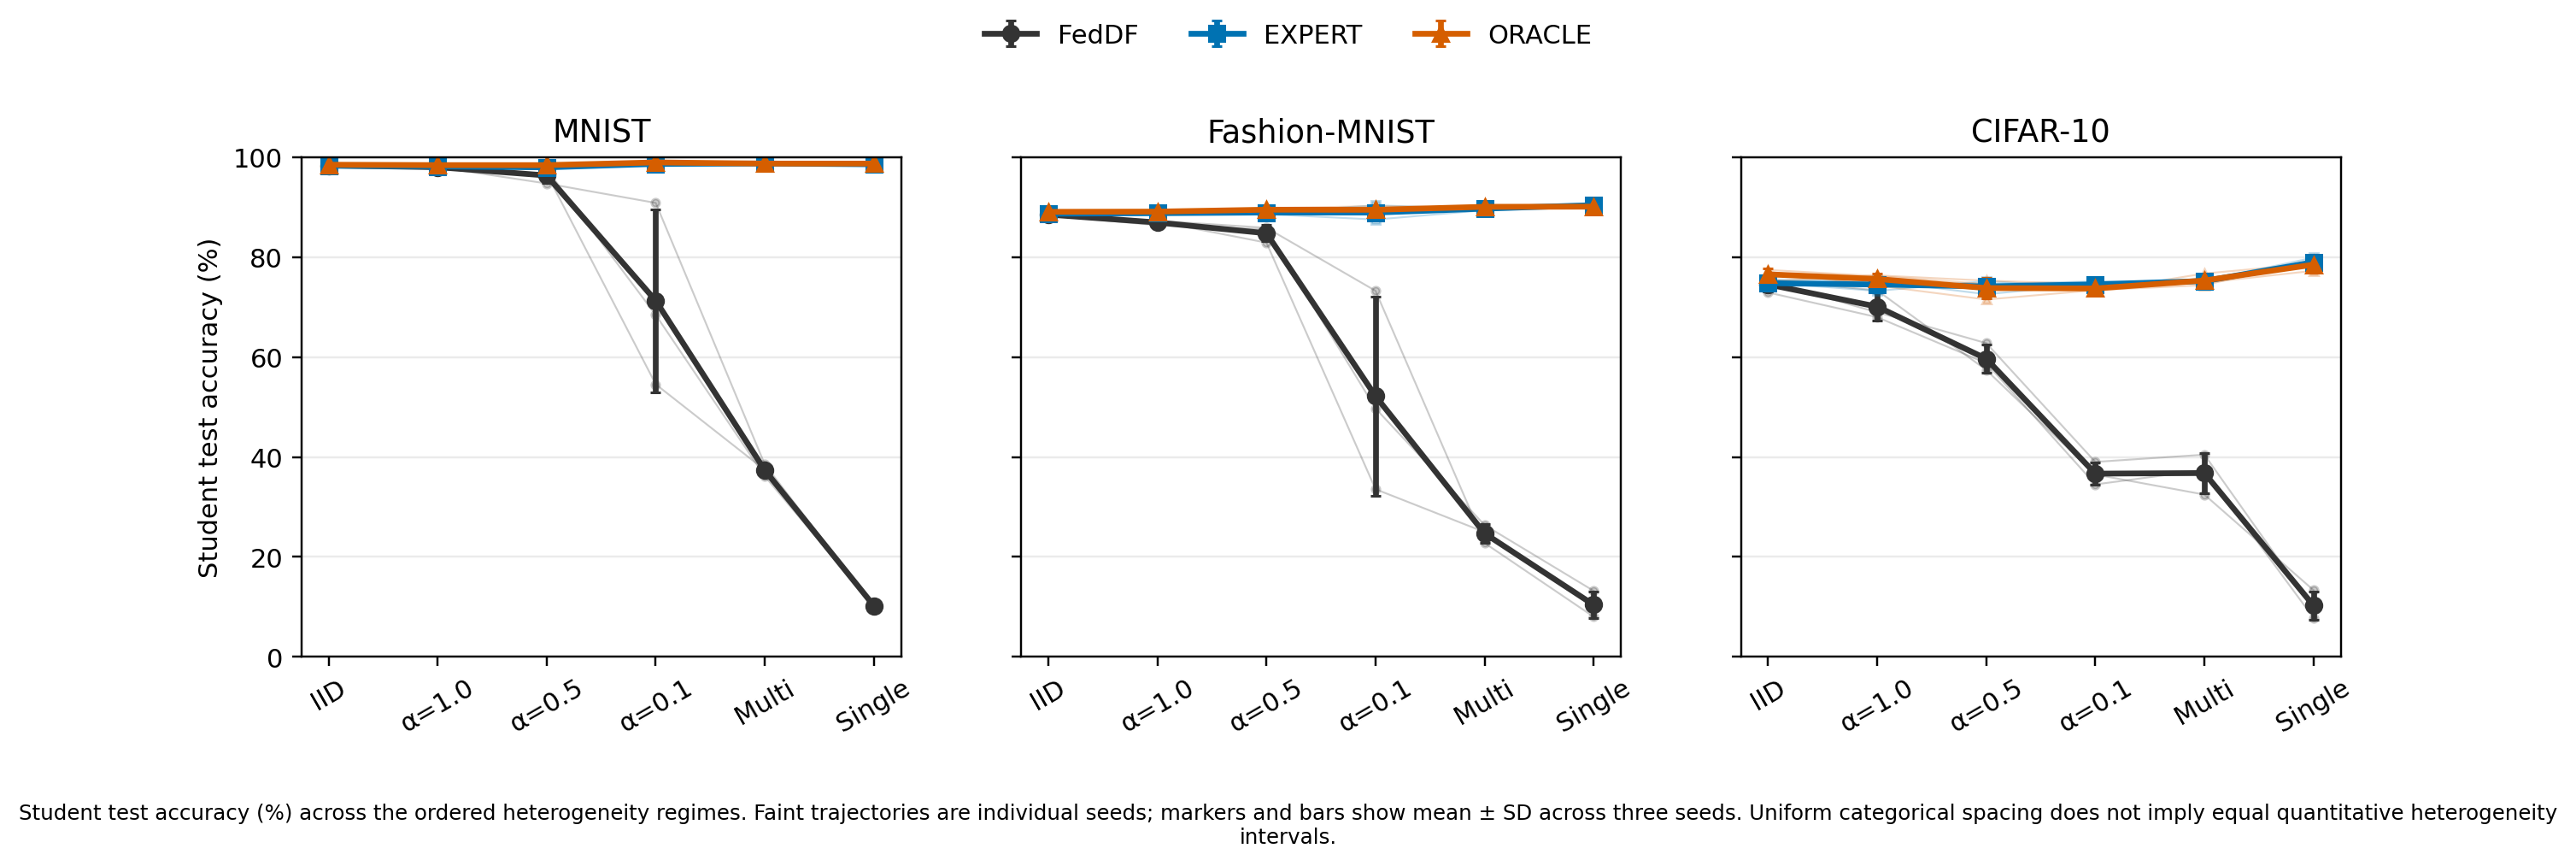

**Figure RQ1-A.** Student test accuracy (%) for FedDF, EXPERT and the informed-sample ORACLE reference across the ordered heterogeneity regimes IID → α=1.0 → α=0.5 → α=0.1 → Multi → Single. Faint trajectories are seeds; markers and bars are mean ± SD across three seeds. Uniform category spacing does not imply equal heterogeneity intervals.

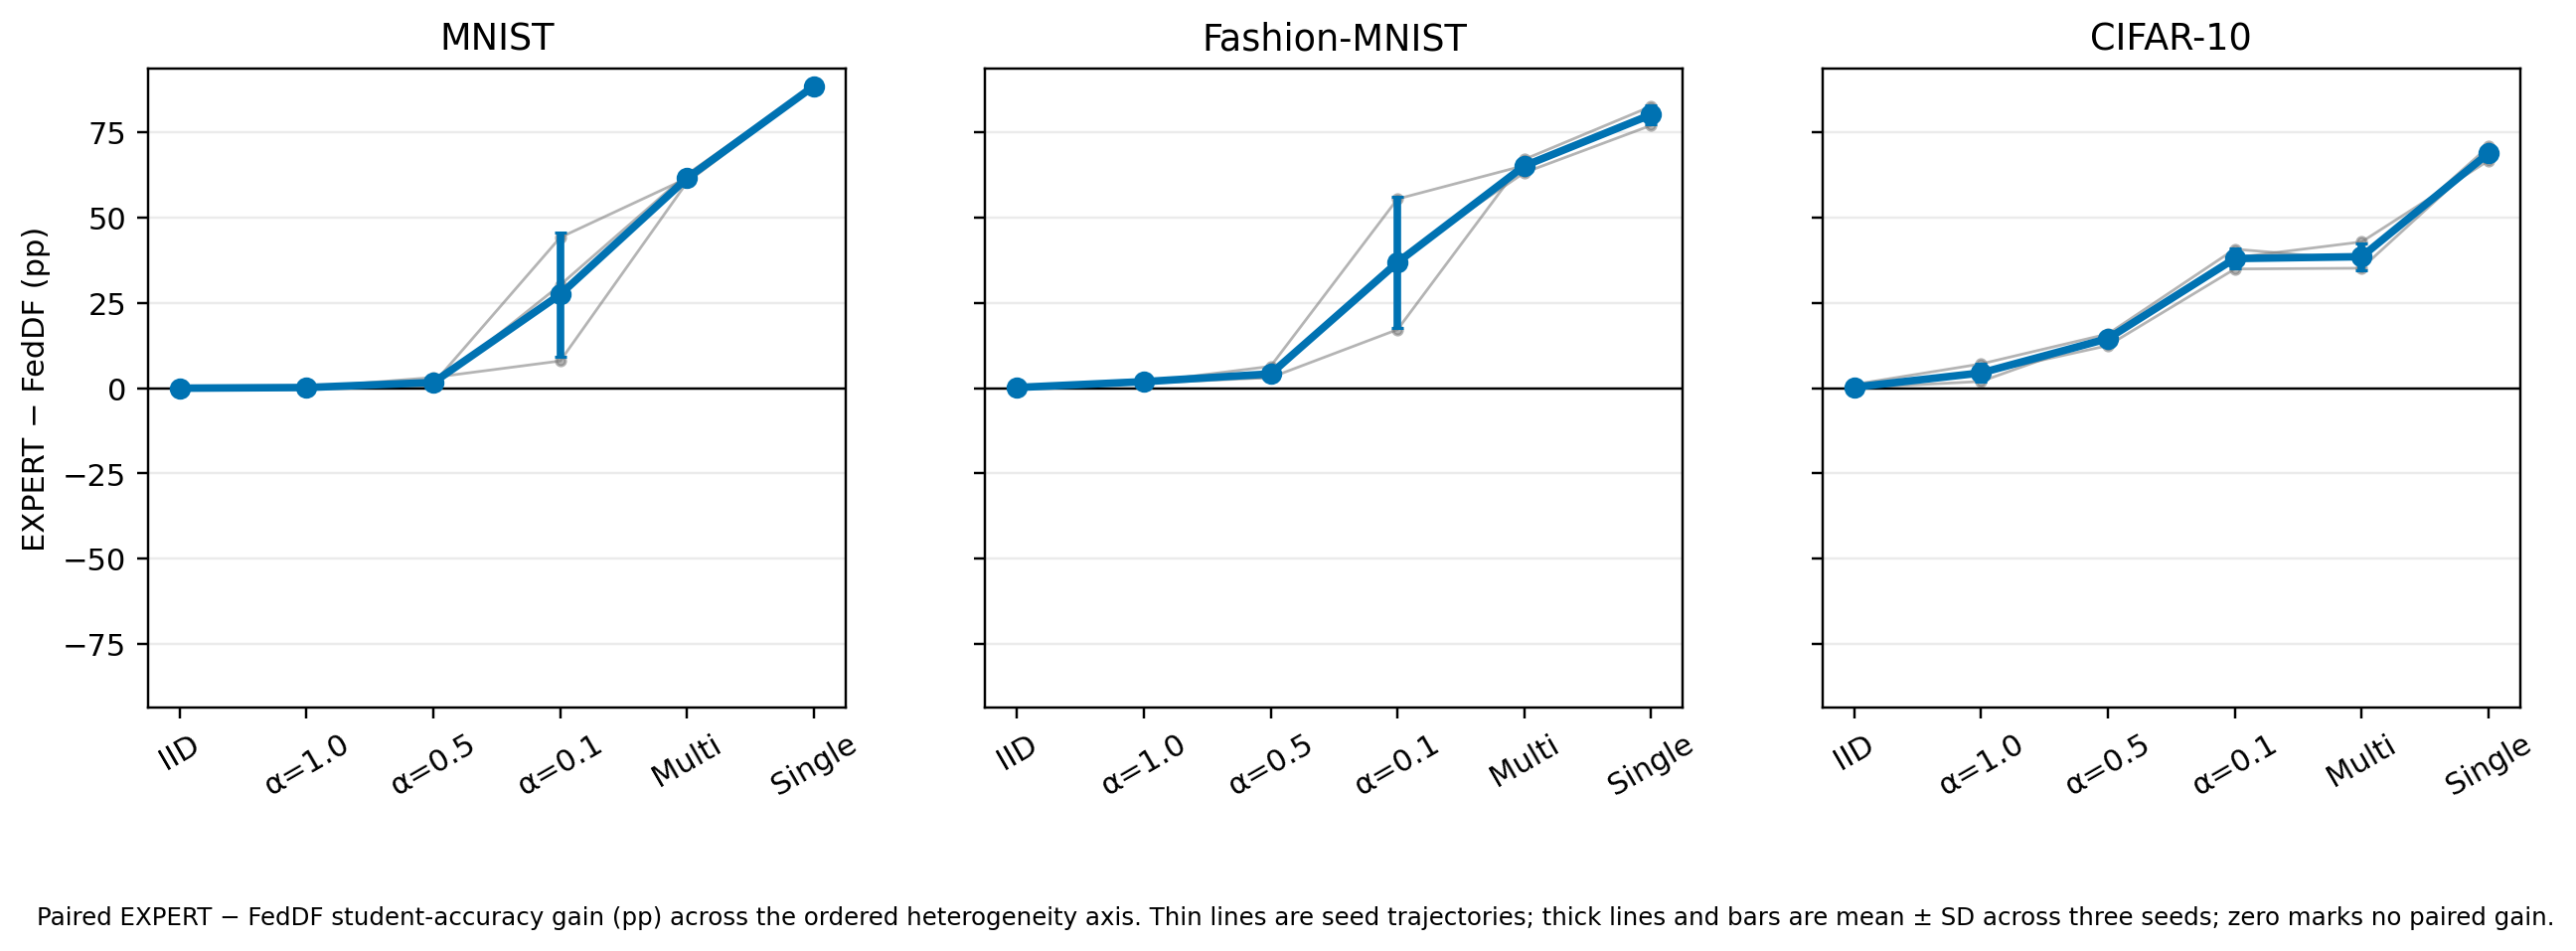

**Figure RQ1-B.** Paired EXPERT − FedDF student-accuracy gain in percentage points across the ordered heterogeneity axis. Thin trajectories are individual seeds; thick estimates and error bars are mean ± SD across three seeds; zero denotes no paired gain.

In [3]:
rq1_effects = pd.read_csv(OUT / 'tables' / 'table_rq1_paired_effects.csv')
rq1_effects_summary = pd.read_csv(OUT / 'tables' / 'table_rq1_paired_effects_summary.csv')
rq1_gap = pd.read_csv(OUT / 'tables' / 'table_rq1_oracle_gap.csv')
display(rq1_effects[['dataset', 'regime', 'seed', 'expert_minus_feddf_pp']])
display(rq1_effects_summary)
display(pd.read_csv(OUT / 'tables' / 'table_rq1_trajectory.csv'))
display(rq1_gap)
display(pd.read_csv(OUT / 'tables' / 'table_rq1_internal_controls.csv').head(18))
display(pd.read_csv(OUT / 'tables' / 'table_rq1_expert_internal_paired.csv').head(18))
display(Image(filename=str(OUT / 'figures' / 'fig_rq1_student_accuracy.png')))
display(Markdown('**Figure RQ1-A.** Student test accuracy (%) for FedDF, EXPERT and the informed-sample ORACLE reference across the ordered heterogeneity regimes IID → α=1.0 → α=0.5 → α=0.1 → Multi → Single. Faint trajectories are seeds; markers and bars are mean ± SD across three seeds. Uniform category spacing does not imply equal heterogeneity intervals.'))
display(Image(filename=str(OUT / 'figures' / 'fig_rq1_expertise_gain.png')))
display(Markdown('**Figure RQ1-B.** Paired EXPERT − FedDF student-accuracy gain in percentage points across the ordered heterogeneity axis. Thin trajectories are individual seeds; thick estimates and error bars are mean ± SD across three seeds; zero denotes no paired gain.'))


## 4. RQ2 — Logits versus probabilities

All comparisons retain identical EXPERT routing. The T=8 result is primary; the ORACLE aggregation-space comparison is a secondary control only.

,dataset,regime,mean_pp,sd_pp,mae_pp,median_abs_pp,max_abs_pp,within_0_5pp,within_1pp,n,positives,negatives,ties
0,cifar,alpha0p1,0.573333,0.354730,0.573333,0.64,0.89,1,3,3,3,0,0
1,cifar,alpha0p5,0.666667,0.366652,0.666667,0.46,1.09,2,2,3,3,0,0
2,cifar,alpha1p0,0.273333,0.663802,0.440000,0.25,1.02,2,2,3,2,1,0
3,cifar,iid,0.183333,0.202073,0.183333,0.15,0.40,3,3,3,2,0,1
4,cifar,multi,0.296667,1.006197,0.750000,0.68,1.33,1,2,3,2,1,0
5,cifar,single,-0.780000,0.532259,0.780000,0.54,1.39,1,2,3,0,3,0
6,fmnist,alpha0p1,-0.073333,0.100167,0.093333,0.08,0.17,3,3,3,1,2,0
7,fmnist,alpha0p5,0.310000,0.236432,0.310000,0.34,0.53,2,3,3,3,0,0
8,fmnist,alpha1p0,0.036667,0.113725,0.096667,0.09,0.13,3,3,3,2,1,0
9,fmnist,iid,0.056667,0.080829,0.076667,0.07,0.13,3,3,3,2,1,0


,scope,mean_pp,sd_pp,mae_pp,median_abs_pp,max_abs_pp,within_0_5pp,within_1pp,n,positives,negatives,ties
0,overall,0.087037,0.430847,0.277778,0.125,1.39,44,50,54,35,18,1


,scope,mean_pp,sd_pp,mae_pp,median_abs_pp,max_abs_pp,within_0_5pp,within_1pp,n,positives,negatives,ties
0,overall,0.100926,0.462721,0.320185,0.185,1.39,41,50,54,27,24,3


,regime,temperature,mean_pp,sd_pp,seed_values_pp,mae_pp,max_abs_pp,within_1pp,n
0,alpha0p1,1.0,-3.916667,0.340783,"[-3.710000000000002, -3.73, -4.309999999999992]",3.916667,4.31,0,3
1,alpha0p1,4.0,0.436667,1.315003,"[0.44000000000000705, 1.749999999999996, -0.88...",1.023333,1.75,2,3
2,alpha0p1,8.0,0.573333,0.354730,"[0.6399999999999961, 0.8900000000000019, 0.190...",0.573333,0.89,3,3
3,iid,1.0,-1.153333,1.175982,"[-0.8199999999999985, -0.18000000000000238, -2...",1.153333,2.46,2,3
4,iid,4.0,-0.310000,0.173494,"[-0.11999999999999789, -0.45999999999999375, -...",0.310000,0.46,3,3
5,iid,8.0,0.183333,0.202073,"[0.15000000000000568, 0.40000000000000036, 0.0]",0.183333,0.40,3,3
6,single,1.0,0.080000,0.138564,"[0.24000000000000687, 0.0, 0.0]",0.080000,0.24,3,3
7,single,4.0,0.063333,0.109697,"[0.19000000000000128, 0.0, 0.0]",0.063333,0.19,3,3
8,single,8.0,-0.780000,0.532259,"[-0.5400000000000071, -0.40999999999999925, -1...",0.780000,1.39,2,3


,regime,temperature,seed,space_delta_pp
0,iid,8.0,42,0.15
1,alpha0p1,8.0,42,0.64
2,single,8.0,42,-0.54
3,iid,8.0,43,0.40
4,alpha0p1,8.0,43,0.89
5,single,8.0,43,-0.41
6,iid,8.0,44,0.00
7,alpha0p1,8.0,44,0.19
8,single,8.0,44,-1.39
9,iid,1.0,42,-0.82


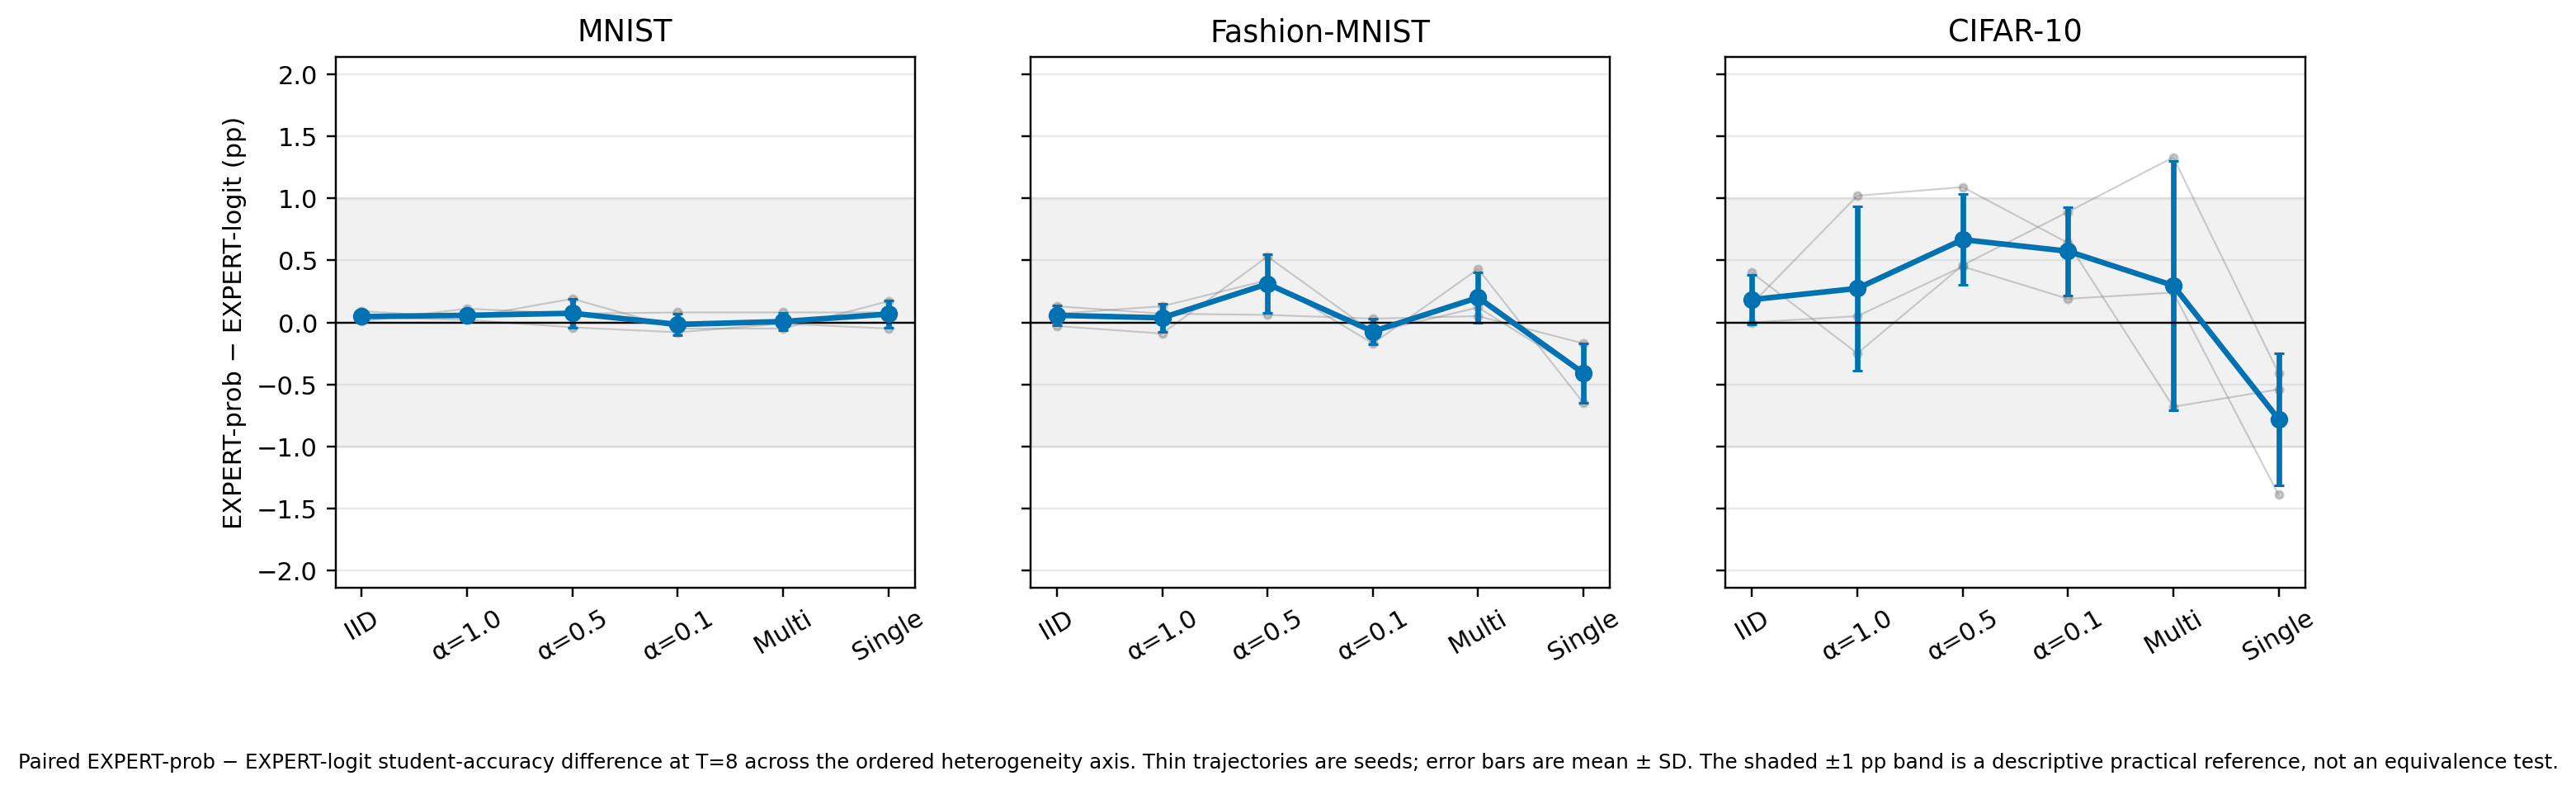

**Figure RQ2-A.** Paired EXPERT-prob − EXPERT-logit student-accuracy difference at T=8, in percentage points. Each point is one seed; error bars are mean ± SD across three seeds. The grey band is the practical ±1 pp reference, not a significance or equivalence test.

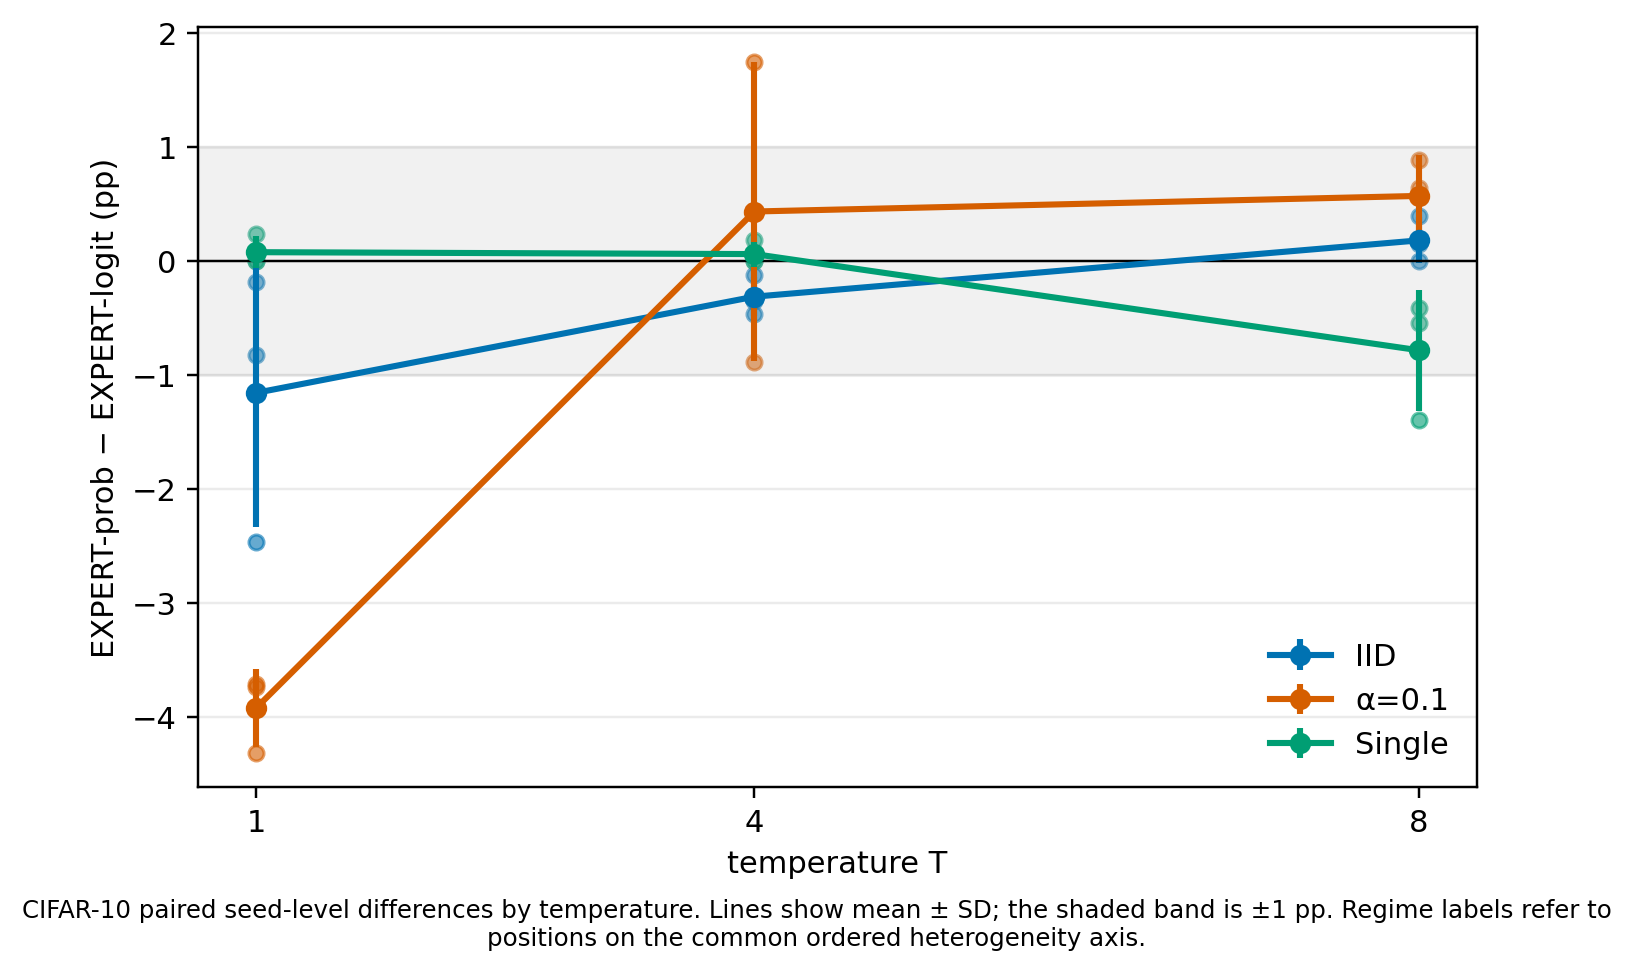

**Figure RQ2-B.** CIFAR-10 paired EXPERT-prob − EXPERT-logit student-accuracy difference by temperature. Coloured series identify regime; individual points are seeds and bars are mean ± SD. The grey band marks ±1 pp, while sign indicates the direction of the probability-space contrast.

In [4]:
display(pd.read_csv(OUT / 'tables' / 'table_rq2_t8_summary.csv'))
display(pd.read_csv(OUT / 'tables' / 'table_rq2_t8_global_summary.csv'))
display(pd.read_csv(OUT / 'tables' / 'table_rq2_oracle_space_control.csv'))
temperature_summary = pd.read_csv(OUT / 'tables' / 'table_rq2_temperature_summary.csv')
temperature_paired = pd.read_csv(OUT / 'tables' / 'table_rq2_temperature_paired.csv')
display(temperature_summary[['regime', 'temperature', 'mean_pp', 'sd_pp', 'seed_values_pp', 'mae_pp', 'max_abs_pp', 'within_1pp', 'n']])
display(temperature_paired[['regime', 'temperature', 'seed', 'space_delta_pp']])
display(Image(filename=str(OUT / 'figures' / 'fig_rq2_logit_probability_t8.png')))
display(Markdown('**Figure RQ2-A.** Paired EXPERT-prob − EXPERT-logit student-accuracy difference at T=8, in percentage points. Each point is one seed; error bars are mean ± SD across three seeds. The grey band is the practical ±1 pp reference, not a significance or equivalence test.'))
display(Image(filename=str(OUT / 'figures' / 'fig_rq2_temperature_sensitivity.png')))
display(Markdown('**Figure RQ2-B.** CIFAR-10 paired EXPERT-prob − EXPERT-logit student-accuracy difference by temperature. Coloured series identify regime; individual points are seeds and bars are mean ± SD. The grey band marks ±1 pp, while sign indicates the direction of the probability-space contrast.'))


## 5. Claim–evidence ledger

Claims are limited to descriptive evidence. The ±1 pp band is a practical reference, not a significance or equivalence test.

In [5]:
display(Markdown((OUT / 'rq1_rq2_claims.md').read_text(encoding='utf-8')))


# RQ1/RQ2 claim–evidence ledger

## RQ1 — Need for expertise

### Observación

En 8/9 trayectorias dataset–seed del eje completo IID→α=1.0→α=0.5→α=0.1→multi→single, EXPERT−FedDF es no decreciente. Las excepciones se registran explícitamente en `table_rq1_trajectory.csv`; la tendencia media aumenta a través del eje. El gap ORACLE−EXPERT medio firmado es 0.250 pp (MAE 0.574 pp).

### Interpretación

El patrón es compatible con que el routing por expertise sea más útil cuando la especialización de clase hace menos apropiado promediar a todos los teachers. ORACLE es una referencia informada por muestra para contextualizar el routing, no un techo del estudiante.

### Claim defendible

En este protocolo, la ventaja de EXPERT sobre FedDF aumenta de forma descriptiva a través de los regímenes ordenados de heterogeneidad, aunque una trayectoria individual puede presentar una excepción local.

### Lo que no demuestra

No demuestra causalidad únicamente desde accuracy, ni que EXPERT reproduzca ORACLE, ni que las separaciones categóricas uniformes del eje correspondan a incrementos cuantitativos idénticos de heterogeneidad.

## RQ2 — Logits frente a probabilidades

### Observación

A T=8, EXPERT-prob−EXPERT-logit tiene media 0.087 pp, SD 0.431 pp, MAE 0.278 pp y 50/54 condiciones dentro de ±1 pp. En CIFAR a T=1, el mayor valor absoluto de la media por régimen es 3.917 pp.

### Interpretación

Con routing EXPERT idéntico, el espacio de agregación tiene un efecto práctico pequeño en conjunto a T=8, pero la sensibilidad CIFAR muestra que esa similitud no se extiende automáticamente a temperaturas bajas.

### Claim defendible

Bajo la receta canónica T=8, logits y probabilidades producen resultados de estudiante mayoritariamente cercanos, pero la robustez frente a temperatura es limitada: el efecto depende del régimen y puede ser material a T=1.

### Lo que no demuestra

No demuestra equivalencia matemática entre operadores, invarianza fuera de T=1,4,8, ni una temperatura óptima. El control ORACLE a T=8 es secundario y no convierte ORACLE en un upper bound del estudiante.

## Ledger

| claim | evidence | figure/table | status | limitation |
|---|---|---|---|---|
| Expertise gain increases across the ordered heterogeneity axis | 8/9 nondecreasing seed trajectories | fig_rq1_expertise_gain; table_rq1_paired_effects | qualified | One local trajectory exception; descriptive, three seeds, protocol-specific |
| EXPERT is close to ORACLE in every condition | Oracle gap has max absolute 2.980 pp | table_rq1_oracle_gap | unsupported | Do not use in narrative; gaps remain condition-dependent |
| Aggregation space is practically limited at T=8 | 50/54 within ±1 pp, MAE 0.278 pp | fig_rq2_logit_probability_t8; table_rq2_t8_summary | qualified | Some condition-level effects exceed ±1 pp |
| T=8 similarity is temperature-invariant | CIFAR T=1 has up to 3.917 pp mean absolute regime effect | fig_rq2_temperature_sensitivity; table_rq2_temperature_summary | unsupported | Do not use in narrative |


## 6. Exported files


In [6]:
display(pd.DataFrame({'export': report['exports']}))


,export
0,/home/roi/PycharmProjects/KD_v5/OUTPUTS/articl...
1,/home/roi/PycharmProjects/KD_v5/OUTPUTS/articl...
2,/home/roi/PycharmProjects/KD_v5/OUTPUTS/articl...
3,/home/roi/PycharmProjects/KD_v5/OUTPUTS/articl...
4,/home/roi/PycharmProjects/KD_v5/OUTPUTS/articl...
5,/home/roi/PycharmProjects/KD_v5/OUTPUTS/articl...
6,/home/roi/PycharmProjects/KD_v5/OUTPUTS/articl...
7,/home/roi/PycharmProjects/KD_v5/OUTPUTS/articl...
8,/home/roi/PycharmProjects/KD_v5/OUTPUTS/articl...
9,/home/roi/PycharmProjects/KD_v5/OUTPUTS/articl...


## 7. RQ3 — Pending

No support-restriction, threshold-sensitivity, or RQ3 analysis is performed in this notebook.